# SeSE: Semantic Structural Entropy with Trainable Parameters
### Black-Box Uncertainty Quantification for LLMs — Claim-Level Hallucination Detection

---

**Paper:** *SeSE: Black-Box Uncertainty Quantification for Large Language Models Based on Structural Information Theory* (arXiv 2511.16275v3)

**What this notebook covers:**
| Section | Content |
|---------|---------|
| 1 | Installation & imports |
| 2 | Trainable parameter module (`SeSEParams`) |
| 3 | Data structures |
| 4 | Semantic graph builder |
| 5 | Structural entropy calculator |
| 6 | Encoding tree optimizer (Algorithm 1) |
| 7 | SeSE short-form scoring |
| 8 | SeSE long-form (claim-level) scoring |
| 9 | Training loop (BCE fine-tuning) |
| 10 | Demo: short-form uncertainty |
| 11 | Demo: long-form claim classification table |
| 12 | Visualization: entailment heatmap + score plots |
| 13 | Hyperparameter sensitivity analysis |

**Trainable parameters introduced:**

| Parameter | Symbol | Paper default | Description |
|-----------|--------|---------------|-------------|
| `alpha` | α | 1.0 | Entailment edge weight (Eq. 7) |
| `beta` | β | 0.5 | Neutral edge weight (Eq. 7) |
| `gamma` | γ | ~0 | Contradiction edge weight (Eq. 7) |
| `merge_threshold` | Δ | 0 (hard) | Soft stopping for tree merging (Alg. 1) |
| `depth_discount` | λ | 1.0 | Path entropy depth weighting (Eq. 16) |
| `temperature` | τ | 1.0 | Transition matrix sharpness |


## 1. Installation & Imports

In [22]:
# Install required packages
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "torch", "numpy", "matplotlib", "seaborn", "pandas",
                "--quiet"], check=False)

print("Packages ready")


Packages ready


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from copy import deepcopy
import warnings
warnings.filterwarnings("ignore")

# Matplotlib dark style
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#0f1117",
    "axes.edgecolor":   "#2d3748",
    "axes.labelcolor":  "#e2e8f0",
    "xtick.color":      "#718096",
    "ytick.color":      "#718096",
    "text.color":       "#e2e8f0",
    "grid.color":       "#2d3748",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "font.family":      "monospace",
    "figure.dpi":       110,
})

torch.manual_seed(42)
np.random.seed(42)
print("Imports complete")


Imports complete


## 2. Trainable Parameter Module

All six learnable scalars live in `SeSEParams`, a standard `nn.Module`.  
They are stored in log-space for positivity constraints and exposed via
properties.


In [24]:
class SeSEParams(nn.Module):
    """
    Trainable parameters for SeSE.

    All parameters are stored in log/unconstrained space and exposed via
    properties that apply the appropriate transform (exp, sigmoid, etc.).

    Gradient flow is preserved through all downstream computations,
    enabling end-to-end fine-tuning with any PyTorch optimizer.
    """

    def __init__(self):
        super().__init__()

        # ── Edge weight coefficients: W = alpha*pe + beta*pn + gamma*pc
        # FIXED at paper defaults: alpha=1, beta=0.5, gamma=0  (requires_grad=False)
        self.log_alpha = nn.Parameter(torch.tensor(0.0),      requires_grad=False)  # exp(0) = 1.0
        self.log_beta  = nn.Parameter(torch.tensor(-0.6931),  requires_grad=False)  # exp ≈ 0.5
        self.log_gamma = nn.Parameter(torch.tensor(-1e9),     requires_grad=False)  # exp ≈ 0 (hard gamma=0)

        # ── Merge / combine threshold  FIXED at 0 (hard threshold, paper setting)
        self.merge_threshold_param = nn.Parameter(torch.tensor(0.0), requires_grad=False)

        # ── Depth discount for long-form path entropy (Eq. 16)
        # FIXED: sigmoid(0)*2 = 1.0  → no discount
        self.log_depth_discount = nn.Parameter(torch.tensor(0.0), requires_grad=False)

        # ── Transition matrix temperature  FIXED at 1.0
        self.log_temperature = nn.Parameter(torch.tensor(0.0), requires_grad=False)  # exp(0) = 1.0

        # --- Refinement Parameters (still trainable) ---
        self.sparsity_threshold_param = nn.Parameter(torch.tensor(0.15))
        self.lazy_weight_param = nn.Parameter(torch.tensor(0.1))

    # ── Constrained accessors ────────────────────────────────────────────────

    @property
    def alpha(self) -> torch.Tensor:
        """Entailment weight  α > 0"""
        return torch.exp(self.log_alpha)

    @property
    def beta(self) -> torch.Tensor:
        """Neutral weight  β > 0"""
        return torch.exp(self.log_beta)

    @property
    def gamma(self) -> torch.Tensor:
        """Contradiction weight  γ > 0"""
        return torch.exp(self.log_gamma)

    @property
    def merge_threshold(self) -> torch.Tensor:
        return self.merge_threshold_param

    @property
    def depth_discount(self) -> torch.Tensor:
        """Depth discount  λ ∈ (0, 2)"""
        return torch.sigmoid(self.log_depth_discount) * 2.0

    @property
    def temperature(self) -> torch.Tensor:
        """Temperature  τ ∈ [0.1, 5.0]"""
        return torch.exp(self.log_temperature).clamp(0.1, 5.0)

    @property
    def sparsity_threshold(self) -> torch.Tensor:
        return self.sparsity_threshold_param

    @property
    def lazy_weight(self) -> torch.Tensor:
        return self.lazy_weight_param

    def summary(self) -> dict:
        """Return readable dict of current parameter values."""
        return {
            "alpha  (entailment weight)":    round(self.alpha.item(), 4),
            "beta   (neutral weight)":       round(self.beta.item(), 4),
            "gamma  (contradiction weight)": round(self.gamma.item(), 4),
            "merge_threshold":               round(self.merge_threshold.item(), 4),
            "depth_discount":                round(self.depth_discount.item(), 4),
            "temperature":                   round(self.temperature.item(), 4),
            "sparsity_threshold":            round(self.sparsity_threshold.item(), 4),
            "lazy_weight":                   round(self.lazy_weight.item(), 4),
        }

    def reset_to_paper_defaults(self):
        """Reset all parameters to the values used in the original paper."""
        with torch.no_grad():
            self.log_alpha.fill_(0.0)
            self.log_beta.fill_(-0.6931)
            self.log_gamma.fill_(-4.0)
            self.merge_threshold_param.fill_(0.0)
            self.log_depth_discount.fill_(0.0)
            self.log_temperature.fill_(0.0)
            self.sparsity_threshold_param.fill_(0.15)
            self.lazy_weight_param.fill_(0.1)
        print("Reset to paper defaults")


# ── Quick sanity check ───────────────────────────────────────────────────────
params = SeSEParams()
print("Initial parameter values:")
for k, v in params.summary().items():
    print(f"  {k:<40} {v}")
print(f"\nTotal trainable scalars: {sum(p.numel() for p in params.parameters())}")

Initial parameter values:
  alpha  (entailment weight)               1.0
  beta   (neutral weight)                  0.5
  gamma  (contradiction weight)            0.0
  merge_threshold                          0.0
  depth_discount                           1.0
  temperature                              1.0
  sparsity_threshold                       0.15
  lazy_weight                              0.1

Total trainable scalars: 8


## 3. Data Structures

In [25]:
@dataclass
class NLIScore:
    """
    Output of a Natural Language Inference model for a (premise, hypothesis) pair.
    Values should sum to ~1.0.
    """
    entailment:    float   # premise → hypothesis entails
    neutral:       float   # no clear relationship
    contradiction: float   # premise → hypothesis contradicts


@dataclass
class TreeNode:
    """Node in an encoding tree T."""
    idx:      int
    children: List["TreeNode"] = field(default_factory=list)
    members:  List[int]        = field(default_factory=list)   # vertex indices
    parent:   Optional["TreeNode"] = field(default=None, repr=False)

    def is_leaf(self) -> bool:
        return len(self.children) == 0

    def depth(self) -> int:
        """Depth of this node from the root (root = 0)."""
        d = 0
        node = self
        while node.parent is not None:
            d += 1
            node = node.parent
        return d


@dataclass
class ClaimResult:
    """Result for a single atomic claim after SeSE long-form scoring."""
    claim_id:    int
    claim_text:  str
    sese_score:  float          # structural entropy along path to this claim
    label:       str            # "HALLUCINATION" or "FACTUAL"
    confidence:  float          # distance from support threshold, normalised 0-1
    support_pct: float          # % of sampled responses that entail this claim
    support_count: int          # raw count


print(" Data structures defined")
print("  NLIScore, TreeNode, ClaimResult")


 Data structures defined
  NLIScore, TreeNode, ClaimResult


## 4. Semantic Graph Builder(Aamr will update the code based on the structure of the semantic graph to make sure the elements of the claims macthes together)

Constructs the directed weighted graph **G = (V, E, W)** from pairwise NLI scores.

**Key equation (Eq. 7 of the paper):**
$$W(v_i, v_j) = \alpha \cdot p_e + \beta \cdot p_n + \gamma \cdot p_c$$

**Trainable change:** α, β, γ replace the paper's fixed `[1, 0.5, 0]`.

The transition matrix **P** is then computed with a learnable temperature τ:
$$P(v_i, v_j) = \frac{W(v_i, v_j) / \tau}{\sum_k W(v_i, v_k) / \tau}$$


In [26]:
import torch
from typing import List, NamedTuple

class SemanticGraphBuilder:
    """
    Builds an adaptively sparsified directed weighted graph from pairwise NLI scores,
    incorporating lazy random walks for stationary distribution stability.
    """

    def __init__(self, params: SeSEParams):
        self.params = params

    # ── Graph construction ───────────────────────────────────────────────────

    def build_weight_matrix(self, nli_scores: List[List[NLIScore]]) -> torch.Tensor:
        """
        Build N×N weight matrix W using trainable (alpha, beta, gamma).
        Diagonal is zero (no self-loops initially).

        Args:
            nli_scores: nli_scores[i][j] = NLIScore for response_i → response_j

        Returns:
            W: (N, N) float tensor
        """
        N = len(nli_scores)
        W = torch.zeros(N, N)

        alpha = self.params.alpha
        beta  = self.params.beta
        gamma = self.params.gamma

        for i in range(N):
            for j in range(N):
                if i == j:
                    continue
                s  = nli_scores[i][j]
                pe = torch.tensor(s.entailment,    dtype=torch.float32)
                pn = torch.tensor(s.neutral,       dtype=torch.float32)
                pc = torch.tensor(s.contradiction, dtype=torch.float32)

                # Calculate raw combined score
                W[i, j] = alpha * pe + beta * pn + gamma * pc

        return W   # shape: (N, N)

    # ── Transition matrix ────────────────────────────────────────────────────

    def to_transition_matrix(self, W: torch.Tensor) -> torch.Tensor:
        """
        Convert weight matrix to row-stochastic transition matrix P.
        Applies adaptive sparsification and lazy random walks (self-loops).

        Returns:
            P: (N, N) row-stochastic float tensor
        """
        T = self.params.temperature
        eye = torch.eye(W.shape[0])

        # 1. Adaptive Sparsification
        # Zero out weak connections below the threshold to remove noise.
        # We also apply ReLU to ensure non-negativity (in case gamma creates negative weights)
        threshold = W.mean()
        W_sparse = torch.sigmoid((W - threshold) * 10) * W
        W_sparse = torch.relu(W_sparse)

        # 2. Temperature scaling (ensure no self-loops at this stage)
        W_scaled = (W_sparse / T) * (1.0 - eye)

        # Row sums for normalization
        row_sums = W_scaled.sum(dim=1, keepdim=True)
        zero_rows = (row_sums.squeeze() == 0)

        # Avoid division by zero
        row_sums = row_sums.clamp(min=1e-9)
        P = W_scaled / row_sums

        # Uniform fallback for isolated vertices (nodes with no outgoing edges left)
        N = W.shape[0]
        P[zero_rows] = 1.0 / N

        # 3. Self-Loop Handling (Lazy Random Walk)
        # Formula: P_lazy = (1 - λ)P + λI
        # This guarantees the Markov chain is aperiodic and irreducible (ergodic),
        # ensuring the power iteration will always converge.
        lw = self.params.lazy_weight
        P = (1.0 - lw) * P + lw * eye

        return P   # shape: (N, N)

    # ── Stationary distribution ──────────────────────────────────────────────

    @staticmethod
    def stationary_distribution(P: torch.Tensor,
                                 max_iter: int = 1000,
                                 tol: float = 1e-8) -> torch.Tensor:
        """
        Power iteration to find π s.t.  π @ P = π.
        Returns π of shape (N,).
        """
        N  = P.shape[0]
        pi = torch.ones(N) / N

        for _ in range(max_iter):
            pi_new = pi @ P
            if torch.norm(pi_new - pi, p=1) < tol: # Using L1 norm for probability distributions is standard practice
                break
            pi = pi_new

        # BUG FIX 1: Removed .detach() so gradients flow back through pi
        # into alpha/beta/gamma/temperature/lazy_weight during training.
        # Previously detaching pi meant those params got zero gradient
        # contribution from the stationary-distribution computation path.
        return pi / pi.sum().clamp(min=1e-9)


# ── Quick test ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    params_test = SeSEParams()
    builder     = SemanticGraphBuilder(params_test)

    # Dummy 3-response NLI scores
    # R0 and R1 are somewhat similar, R2 is highly contradictory
    dummy_nli = [
        [NLIScore(1,0,0), NLIScore(0.8,0.1,0.1), NLIScore(0.1,0.2,0.7)],
        [NLIScore(0.7,0.2,0.1), NLIScore(1,0,0), NLIScore(0.1,0.1,0.8)],
        [NLIScore(0.1,0.2,0.7), NLIScore(0.2,0.2,0.6), NLIScore(1,0,0)],
    ]

    W  = builder.build_weight_matrix(dummy_nli)
    P  = builder.to_transition_matrix(W)
    pi = builder.stationary_distribution(P)

    print("Weight matrix W (Raw):")
    print(W.detach().numpy().round(3))
    print("\nTransition matrix P (Sparsified + Lazy Self-Loops):")
    print(P.detach().numpy().round(3))
    print("\nStationary distribution π:")
    print(pi.detach().numpy().round(4))
    print("Sum of π:", pi.sum().item())

Weight matrix W (Raw):
[[0.   0.85 0.2 ]
 [0.8  0.   0.15]
 [0.2  0.3  0.  ]]

Transition matrix P (Sparsified + Lazy Self-Loops):
[[0.1   0.838 0.062]
 [0.864 0.1   0.036]
 [0.247 0.653 0.1  ]]

Stationary distribution π:
[0.4719 0.4766 0.0515]
Sum of π: 1.0


## 5. Structural Entropy Calculator

Given **π** and **P**, computes the structural entropy assigned to each
encoding-tree node **α** (Equations 10–12 of the paper):

$$V_\alpha = \sum_{v_i \in V} \sum_{v_j \in T_\alpha} \pi(v_i) P(v_i, v_j)$$

$$g_\alpha = \sum_{v_i \notin T_\alpha} \sum_{v_j \in T_\alpha} \pi(v_i) P(v_i, v_j)$$

$$H^T(G; \alpha) = -\frac{g_\alpha}{\text{vol}(G)} \log_2 \frac{V_\alpha}{V_{\alpha^-}}$$


In [27]:
class StructuralEntropy:
    """
    Computes structural entropy contributions H^T(G; α) for each node.

    All computations keep gradients alive so that upstream trainable
    parameters (alpha, beta, gamma, temperature) can be fine-tuned via
    backpropagation through the entropy signal.
    """

    def __init__(self, pi: torch.Tensor, P: torch.Tensor):
        """
        Args:
            pi: stationary distribution (N,)
            P:  transition matrix       (N, N)
        """
        self.pi  = pi          # (N,)
        self.P   = P           # (N, N)
        self.N   = pi.shape[0]
        self.vol = self._compute_vol()

    def _compute_vol(self) -> torch.Tensor:
        """
        vol(G) = Σ_v (d⁺_v + d⁻_v) where degrees are weighted by π.
        """
        out_deg = self.P.sum(dim=1)   # (N,)  out-degree of each vertex
        in_deg  = self.P.sum(dim=0)   # (N,)  in-degree of each vertex
        return (self.pi * (out_deg + in_deg)).sum().clamp(min=1e-9)

    def V_alpha(self, members: List[int]) -> torch.Tensor:
        """
        V_α = total flow INTO the subset T_α from anywhere in V.
        V_α = Σ_{vi∈V} Σ_{vj∈Tα} π(vi) · P(vi, vj)
        """
        m_tensor = torch.tensor(members, dtype=torch.long)
        # (N, N) flow matrix, then sum columns in T_α
        flow = self.pi.unsqueeze(1) * self.P   # (N, N)
        return flow[:, m_tensor].sum().clamp(min=1e-9)

    def g_alpha(self, members: List[int]) -> torch.Tensor:
        """
        g_α = flow from OUTSIDE T_α INTO T_α  (cut weight).
        g_α = Σ_{vi∉Tα} Σ_{vj∈Tα} π(vi) · P(vi, vj)
        """
        m_tensor   = torch.tensor(members, dtype=torch.long)
        not_m      = [i for i in range(self.N) if i not in members]
        if not not_m:
            return torch.tensor(0.0)
        not_tensor = torch.tensor(not_m, dtype=torch.long)
        flow       = self.pi.unsqueeze(1) * self.P   # (N, N)
        return flow[not_tensor][:, m_tensor].sum().clamp(min=1e-9)

    def node_entropy(self,
                     members:        List[int],
                     parent_members: List[int]) -> torch.Tensor:
        """
        H^T(G; α) = -(g_α / vol(G)) · log2(V_α / V_{α−})
        """
        Va     = self.V_alpha(members)
        Va_par = self.V_alpha(parent_members)
        ga     = self.g_alpha(members)
        # print("ga:", ga.item(), "Va:", Va.item(), "Va_par:", Va_par.item())
        ratio  = (Va / Va_par).clamp(min=1e-9)

        return -(ga / self.vol) * torch.log2(ratio)

    def total_entropy(self, root: "TreeNode",
                      depth_discount: Optional[torch.Tensor] = None
                      ) -> torch.Tensor:
        """
        H^T(G) = Σ_{α ≠ λ} H^T(G; α)   (Eq. 4)

        BUG FIX 3: Added optional depth_discount weighting.
        depth_discount (λ) weights each node's entropy by λ^(depth-1),
        matching Eq. 16 and ensuring the parameter receives gradients
        through the short-form forward pass (previously it was only used
        in SeSELongForm._path_entropy, which the trainer never called).
        When depth_discount is None, behaviour is identical to before.
        """
        total = torch.tensor(0.0)

        def _recurse(node: "TreeNode", depth: int):
            nonlocal total
            for child in node.children:
                h = self.node_entropy(child.members, node.members)
                if depth_discount is not None:
                    # BUG FIX: exponent is `depth`, not `depth - 1`.
                    # With depth-1, root's children (depth=1) got dd**0=1 — a
                    # constant with zero gradient. Using dd**depth means
                    # root's children get dd**1=dd, so depth_discount appears
                    # in every level's arithmetic and trains properly.
                    h = h * (depth_discount ** depth)
                total = total + h
                _recurse(child, depth + 1)

        _recurse(root, depth=1)
        return total


print(" StructuralEntropy defined")
print("   Methods: V_alpha, g_alpha, node_entropy, total_entropy")


 StructuralEntropy defined
   Methods: V_alpha, g_alpha, node_entropy, total_entropy


## 6. Encoding Tree Optimizer (Algorithm 1)

Greedy structural-entropy minimisation via **merging** and **combining** operators.

**Trainable change:** The hard threshold `Δ > 0` is replaced by a learnable
`merge_threshold` parameter, allowing the model to learn how aggressively
to grow the tree.

The algorithm iterates until no beneficial merge/combine exists or the
tree reaches height K.


In [28]:
import torch
from typing import List, Tuple, Optional

class EncodingTreeOptimizer:
    """
    Implements Algorithm 1: greedy K-dimensional encoding tree construction
    via structural entropy minimisation, using BOTH Merge and Combine operators.
    """

    def __init__(self, params: SeSEParams, se: StructuralEntropy, K: int = 3):
        self.params = params
        self.se     = se
        self.K      = K
        self._node_counter = 0

    def _new_node(self, members: List[int]) -> TreeNode:
        self._node_counter += 1
        return TreeNode(idx=self._node_counter, members=members)

    # ── Tree utilities ───────────────────────────────────────────────────────

    def _tree_height(self, root: TreeNode) -> int:
        if not root.children:
            return 0
        return 1 + max(self._tree_height(c) for c in root.children)

    def _all_sibling_pairs(self, root: TreeNode) -> List[Tuple[TreeNode, TreeNode]]:
        """Collect all pairs of sibling nodes (same parent) in the tree."""
        pairs = []
        def _recurse(node: TreeNode):
            ch = node.children
            for i in range(len(ch)):
                for j in range(i + 1, len(ch)):
                    pairs.append((ch[i], ch[j]))
            for c in ch:
                _recurse(c)
        _recurse(root)
        return pairs

    # ── MERGE Operator (Vertical) ────────────────────────────────────────────

    def _apply_merge(self, a: TreeNode, b: TreeNode) -> TreeNode:
        """Merge siblings a and b under a new intermediate parent."""
        new_node = self._new_node(a.members + b.members)
        new_node.children = [a, b]
        new_node.parent   = a.parent

        parent = a.parent
        parent.children = [c for c in parent.children if c not in (a, b)]
        parent.children.append(new_node)
        a.parent = new_node
        b.parent = new_node
        return new_node

    def _undo_merge(self, a: TreeNode, b: TreeNode, new_node: TreeNode):
        """Revert a merge operation."""
        parent = new_node.parent
        parent.children = [c for c in parent.children if c is not new_node]
        parent.children.extend([a, b])
        a.parent = parent
        b.parent = parent

    # ── COMBINE Operator (Horizontal) ────────────────────────────────────────

    def _apply_combine(self, target: TreeNode, source: TreeNode):
        """
        Combine (absorb) source into target.
        Target gains source's members and children. Source is removed.
        """
        target.members.extend(source.members)
        target.children.extend(source.children)
        for child in source.children:
            child.parent = target

        parent = target.parent
        parent.children = [c for c in parent.children if c is not source]
        source.parent = None

    def _undo_combine(self, target: TreeNode, source: TreeNode, original_parent: TreeNode):
        """Revert a combine operation."""
        # Remove source's members from target
        target.members = [m for m in target.members if m not in source.members]

        # Remove source's children from target and reassign them to source
        target.children = [c for c in target.children if c not in source.children]
        for child in source.children:
            child.parent = source

        # Reattach source to the parent
        original_parent.children.append(source)
        source.parent = original_parent

    # ── Delta computation ────────────────────────────────────────────────────

    def _delta_merge(self, root: TreeNode, a: TreeNode, b: TreeNode) -> torch.Tensor:
        before = self.se.total_entropy(root)
        new_node = self._apply_merge(a, b)
        after = self.se.total_entropy(root)
        self._undo_merge(a, b, new_node)
        return before - after

    def _delta_combine(self, root: TreeNode, target: TreeNode, source: TreeNode) -> torch.Tensor:
        before = self.se.total_entropy(root)
        original_parent = source.parent
        self._apply_combine(target, source)
        after = self.se.total_entropy(root)
        self._undo_combine(target, source, original_parent)
        return before - after

    # ── Main optimisation loop ───────────────────────────────────────────────

    def _init_tree(self, N: int) -> TreeNode:
        """Initialise flat 1-dimensional encoding tree."""
        root = TreeNode(idx=0, members=list(range(N)))
        for i in range(N):
            leaf = self._new_node([i])
            leaf.parent = root
            root.children.append(leaf)
        return root

    def optimize(self, N: int,
                 depth_discount: Optional[torch.Tensor] = None
                 ) -> Tuple[TreeNode, torch.Tensor]:
        self._node_counter = N
        root = self._init_tree(N)
        threshold = self.params.merge_threshold

        # BUG FIX 2+3 (unified): both merge_threshold and depth_discount feed
        # into the final score here so neither gets a zero gradient.
        #
        # depth_discount is passed in and applied to base_entropy so the
        # depth-weighted entropy is the starting point for the soft score.
        #
        # merge_threshold enters via sigmoid gates on each applied merge's dH:
        #   score = base_entropy(depth_discount) - Σ sigmoid((dH-threshold)*20)*dH
        # This keeps hard tree structure but makes the score differentiable
        # w.r.t. threshold (gradient flows through the sigmoid directly).
        base_entropy = self.se.total_entropy(root, depth_discount)
        applied_deltas: List[torch.Tensor] = []

        max_iterations = N * self.K * 2
        for _ in range(max_iterations):
            current_height = self._tree_height(root)
            if current_height >= self.K:
                break
            pairs = self._all_sibling_pairs(root)

            best_float_delta = threshold.item()  # hard float guard
            best_action = None

            for a, b in pairs:
                d_merge = self._delta_merge(root, a, b)
                if d_merge.item() > best_float_delta:
                    best_float_delta = d_merge.item()
                    best_action = {"type": "merge", "nodes": (a, b), "delta": d_merge}

            if best_action is None:
                break  # local optimum reached

            applied_deltas.append(best_action["delta"])
            self._apply_merge(*best_action["nodes"])

        # Soft-gate: score = base - Σ sigmoid((dH - threshold)*20) * dH
        # This is differentiable w.r.t. threshold while staying numerically close
        # to the hard structural entropy when threshold is well below each dH.
        soft_score = base_entropy
        for dH in applied_deltas:
            gate = torch.sigmoid((dH - threshold) * 20)
            soft_score = soft_score - gate * dH

        return root, soft_score

## 7. SeSE Short-Form Scoring

Puts the pipeline together for short-form (single-answer) generation.
Returns a scalar uncertainty score U(x) ∈ ℝ.


In [29]:
class SeSEShortForm(nn.Module):
    """
    Full SeSE pipeline for short-form generation.

    Pipeline:
        NLI scores  →  Semantic graph  →  Transition matrix
        →  Stationary distribution  →  Structural entropy minimisation
        →  SeSE score
    """

    def __init__(self, params: SeSEParams, K: int = 3):
        super().__init__()
        self.params  = params
        self.K       = K
        self.builder = SemanticGraphBuilder(params)

    def forward(self, nli_scores: List[List[NLIScore]]) -> torch.Tensor:
        """
        Args:
            nli_scores: N×N list of NLIScore objects

        Returns:
            sese_score: scalar tensor (differentiable w.r.t. SeSEParams)
        """
        W  = self.builder.build_weight_matrix(nli_scores)
        P  = self.builder.to_transition_matrix(W)
        pi = self.builder.stationary_distribution(P)
        se = StructuralEntropy(pi, P)

        opt = EncodingTreeOptimizer(self.params, se, K=self.K)
        # Pass depth_discount into optimize() so both depth_discount and
        # merge_threshold enter the same differentiable score expression.
        # Previously soft_score was discarded (_ =) which broke merge_threshold.
        _, sese_score = opt.optimize(len(nli_scores),
                                     depth_discount=self.params.depth_discount)

        return sese_score

    def score_and_decide(self, nli_scores: List[List[NLIScore]],
                          threshold: float = 0.5) -> Tuple[float, str]:
        """
        Score + binary decision: UNCERTAIN / CERTAIN.
        threshold: SeSE value above which we flag as uncertain/hallucinating.
        """
        score = self.forward(nli_scores).item()
        label = "UNCERTAIN" if score > threshold else "CERTAIN"
        return score, label


print(" SeSEShortForm defined")


 SeSEShortForm defined


## 8. SeSE Long-Form — Claim-Level Scoring

For long-form generation, SeSE builds a **claim-response bipartite graph**
and computes per-claim uncertainty via path entropy (Eq. 16):

$$\text{SeSE}(G_{cr}; c) = -\sum_{\alpha \in P(\lambda \to \gamma) \setminus \{\lambda\}}
\frac{g_\alpha}{\text{vol}(G_{cr})} \log_2 \frac{V_\alpha}{V_{\alpha^-}}$$

**Trainable change:** Depth discount λ weights each node's contribution
by λ^(depth−1), so the model can learn to emphasise shallow vs. deep
tree nodes.


In [30]:
class SeSELongForm(nn.Module):
    """
    Claim-level SeSE for long-form generation.

    Builds a claim-response bipartite graph, minimises its structural
    entropy, and computes per-claim path entropy as the uncertainty score.
    """

    def __init__(self, params: SeSEParams, K: int = 3):
        super().__init__()
        self.params  = params
        self.K       = K
        self.builder = SemanticGraphBuilder(params)

    # ── Bipartite graph construction ─────────────────────────────────────────

    def _build_bipartite_weight_matrix(self,
                                        entailment: torch.Tensor   # (R, C)
                                        ) -> torch.Tensor:
        """
        Build (R+C) × (R+C) weight matrix for the bipartite graph.
        Node ordering: [r_0, ..., r_{R-1}, c_0, ..., c_{C-1}]

        Edges:
          response r → claim c   if r entails c  (weight = entailment[r,c])
          claim c   → response r if r entails c  (symmetric back-edge)
        """
        R, C = entailment.shape
        N    = R + C
        W    = torch.zeros(N, N)

        for r in range(R):
            for c in range(C):
                w = entailment[r, c].float()
                W[r,     R + c] = w   # response → claim
                W[R + c, r    ] = w   # claim → response (back-edge)

        return W

    # ── Path entropy (Eq. 16) ────────────────────────────────────────────────

    def _find_path(self, root: TreeNode, target_member: int) -> Optional[List[TreeNode]]:
        """DFS to find the path from root to the leaf containing target_member."""
        if root.is_leaf():
            return [root] if target_member in root.members else None
        for child in root.children:
            path = self._find_path(child, target_member)
            if path is not None:
                return [root] + path
        return None

    def _path_entropy(self, root: TreeNode, claim_node_idx: int,
                       se: StructuralEntropy) -> torch.Tensor:
        """
        Accumulate structural entropy along the path root → leaf(claim),
        weighted by learnable depth_discount^(depth-1).
        """
        path           = self._find_path(root, claim_node_idx)
        depth_discount = self.params.depth_discount

        if path is None or len(path) < 2:
            return torch.tensor(0.0)

        total = torch.tensor(0.0)
        for depth, node in enumerate(path[1:], start=1):
            parent = path[depth - 1]
            h      = se.node_entropy(node.members, parent.members)
            # BUG FIX: use depth_discount**depth (not depth-1) to match
            # the corrected total_entropy weighting.
            total  = total + h * (depth_discount ** depth)

        return total

    # ── Main forward ─────────────────────────────────────────────────────────

    def forward(self,
                entailment: torch.Tensor,   # (R, C) binary {0,1}
                claims:     List[str],
                responses:  List[str],
                threshold:  float = 0.4     # support fraction threshold
                ) -> List[ClaimResult]:
        """
        Classify each claim as FACTUAL or HALLUCINATION.

        Args:
            entailment: (R, C) binary tensor; 1 if response r entails claim c
            claims:     list of claim strings (length C)
            responses:  list of sampled response strings (length R)
            threshold:  fraction of responses that must support a claim
                        for it to be classified FACTUAL (default 0.4 = 40%)

        Returns:
            List of ClaimResult, one per claim
        """
        R, C = entailment.shape
        W    = self._build_bipartite_weight_matrix(entailment)

        # BUG FIX B: Use trainable temperature and lazy_weight instead of
        # hardcoded tau=0.1 / epsilon=1e-2. With hardcoded constants, W is fixed
        # binary data and P never changes between forward calls, so pi always
        # converges to the exact same vector regardless of parameter updates.
        # Now temperature sharpens/softens the transition distribution and
        # lazy_weight controls the self-loop mass — both affect pi.
        tau     = self.params.temperature   # was hardcoded 0.1
        lw      = self.params.lazy_weight   # was hardcoded 1e-2
        eye     = torch.eye(W.shape[0])
        row_sums  = W.sum(dim=1, keepdim=True)
        zero_mask = (row_sums.squeeze() == 0)
        P = torch.softmax(W / tau, dim=1)
        P = (1.0 - lw) * P + lw * eye     # lazy random walk (same as short-form)
        P[zero_mask] = 1.0 / (R + C)

        pi  = self.builder.stationary_distribution(P)
        se  = StructuralEntropy(pi, P)
        opt = EncodingTreeOptimizer(self.params, se, K=self.K)

        # print("First row of P:", P[0])
        # print("Row std:", P[0].std().item())
        # print("All row std avg:", P.std(dim=1).mean().item())

        root, _ = opt.optimize(R + C)

        results = []
        for c_idx in range(C):
            node_idx    = R + c_idx          # claims start at index R
            sese_score  = self._path_entropy(root, node_idx, se).item()

            # Support statistics
            support_count = int(entailment[:, c_idx].sum().item())
            support_frac  = support_count / R if R > 0 else 0.0

            # Classification
            is_halluc  = (support_frac < threshold)
            confidence = min(abs(support_frac - threshold) / max(threshold, 1e-9), 1.0)

            results.append(ClaimResult(
                claim_id      = c_idx,
                claim_text    = claims[c_idx] if c_idx < len(claims) else f"Claim {c_idx}",
                sese_score    = round(sese_score, 4),
                label         = "HALLUCINATION" if is_halluc else "FACTUAL",
                confidence    = round(confidence, 3),
                support_pct   = round(support_frac * 100, 1),
                support_count = support_count,
            ))

        return results


print(" SeSELongForm defined")


 SeSELongForm defined


## 9. Training Loop

Fine-tune `SeSEParams` on labelled examples using binary cross-entropy loss.

Each training example is a dict:
```python
{
    "nli":   List[List[NLIScore]],   # N×N pairwise NLI scores
    "label": int,                    # 1 = hallucinating, 0 = factual
}
```


In [31]:
class SeSETrainer:
    """
    End-to-end trainer for SeSEParams using short-form labelled examples.

    The SeSE uncertainty score is treated as a logit and trained with
    binary cross-entropy loss:
        loss = BCE( sigmoid(SeSE(x)), label )
    """

    def __init__(self, params: SeSEParams,
                 lr: float = 1e-2, K: int = 3):
        self.params    = params
        self.K         = K
        self.model     = SeSEShortForm(params, K=K)
        self.optimizer = torch.optim.Adam(params.parameters(), lr=lr)
        self.loss_fn   = nn.BCEWithLogitsLoss()
        self.history: List[Dict] = []

    # ── Single step ─────────────────────────────────────────────────────────

    def train_step(self,
                   batch_nli:    List[List[List[NLIScore]]],
                   batch_labels: List[int]) -> float:
        """
        One gradient update on a mini-batch.

        Returns:
            loss value (float)
        """
        self.optimizer.zero_grad()
        losses = []

        for nli_scores, label in zip(batch_nli, batch_labels):
            score  = self.model(nli_scores)
            target = torch.tensor([float(label)])
            loss   = self.loss_fn(score.unsqueeze(0), target)
            losses.append(loss)

        total_loss = torch.stack(losses).mean()
        total_loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(self.params.parameters(), max_norm=1.0)
        self.optimizer.step()

        return total_loss.item()

    # ── Full training ────────────────────────────────────────────────────────

    def train(self, dataset: List[Dict],
              epochs: int = 10,
              batch_size: int = 4,
              verbose: bool = True) -> List[float]:
        """
        Train over the dataset for the given number of epochs.

        Returns:
            epoch_losses: list of average loss per epoch
        """
        if verbose:
            print(f"{'='*55}")
            print(f"Training SeSEParams  |  lr={self.optimizer.param_groups[0]['lr']}")
            print(f"Dataset size: {len(dataset)}  |  Epochs: {epochs}  |  Batch: {batch_size}")
            print(f"{'='*55}")
            print(f"Initial params:")
            for k, v in self.params.summary().items():
                print(f"  {k}: {v}")
            print()

        epoch_losses = []

        for epoch in range(epochs):
            # Shuffle dataset
            indices = np.random.permutation(len(dataset))
            shuffled = [dataset[i] for i in indices]

            batch_losses = []
            for i in range(0, len(shuffled), batch_size):
                batch       = shuffled[i : i + batch_size]
                nli_batch   = [ex["nli"]   for ex in batch]
                label_batch = [ex["label"] for ex in batch]
                loss        = self.train_step(nli_batch, label_batch)
                batch_losses.append(loss)

            avg_loss = float(np.mean(batch_losses))
            epoch_losses.append(avg_loss)

            self.history.append({
                "epoch": epoch + 1,
                "loss":  avg_loss,
                **self.params.summary()
            })

            if verbose and (epoch % max(1, epochs // 5) == 0 or epoch == epochs - 1):
                print(f"Epoch {epoch+1:>3}/{epochs}  |  Loss: {avg_loss:.4f}")

        if verbose:
            print(f"\nFinal params:")
            for k, v in self.params.summary().items():
                print(f"  {k}: {v}")

        return epoch_losses

    def plot_training(self):
        """Plot loss curve and parameter evolution."""
        if not self.history:
            print("No training history yet.")
            return

        df = pd.DataFrame(self.history)
        param_cols = [c for c in df.columns if c not in ["epoch", "loss"]]
        n_plots = 1 + len(param_cols)
        ncols = 3
        nrows = (n_plots + ncols - 1) // ncols

        fig, axes_all = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
        axes = axes_all.flatten()
        fig.suptitle("SeSE Training History", fontsize=14, fontweight="bold", y=1.01)

        # Loss
        axes[0].plot(df["epoch"], df["loss"], color="#60a5fa", lw=2)
        axes[0].set_title("Training Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
        axes[0].grid(True, alpha=0.3)

        colors = ["#34d399", "#f59e0b", "#f87171", "#a78bfa", "#67e8f9", "#fb923c"]
        for idx, (col, color) in enumerate(zip(param_cols, colors)):
            ax = axes[idx + 1]
            ax.plot(df["epoch"], df[col], color=color, lw=2)
            ax.set_title(col.split("(")[0].strip())
            ax.set_xlabel("Epoch")
            ax.grid(True, alpha=0.3)

        # Hide unused axes
        for i in range(n_plots, len(axes)):
            axes[i].set_visible(False)

        plt.tight_layout()
        plt.show()


print(" SeSETrainer defined")


 SeSETrainer defined


## 10. Mock NLI & Demo Data

In production, replace `mock_nli()` with calls to:
- **DeBERTa-v3-large-mnli** (paper's choice, open-source)
- **GPT-5-mini** entailment prompts (used for long-form in paper)
- Any NLI model via HuggingFace `transformers`


In [32]:
def mock_nli(response_i: str, response_j: str) -> NLIScore:
    """
    Lightweight NLI simulation based on word overlap.
    Replace with a real NLI model for production use.
    """
    words_i = set(response_i.lower().split())
    words_j = set(response_j.lower().split())

    if not words_i or not words_j:
        return NLIScore(0.33, 0.33, 0.34)

    overlap  = len(words_i & words_j) / max(len(words_i), len(words_j))
    entail   = overlap * 0.85
    contra   = (1.0 - overlap) * 0.35
    neutral  = max(0.0, 1.0 - entail - contra)

    # Normalise to sum to 1
    total = entail + neutral + contra
    return NLIScore(entail/total, neutral/total, contra/total)


def compute_nli_matrix(responses: List[str]) -> List[List[NLIScore]]:
    """Compute full N×N NLI score matrix for a list of responses."""
    N = len(responses)
    return [
        [mock_nli(responses[i], responses[j]) if i != j else NLIScore(1, 0, 0)
         for j in range(N)]
        for i in range(N)
    ]


# ── Demo response sets ───────────────────────────────────────────────────────

LOW_UNCERTAINTY_RESPONSES = [
    "The capital of France is Paris.",
    "Paris is the capital city of France.",
    "France's capital city is Paris.",
    "Paris serves as France's capital.",
    "The city of Paris is the capital of France."
]

HIGH_UNCERTAINTY_RESPONSES = [
    "Paris is the capital of France.",
    "The capital might be Lyon or possibly Marseille.",
    "France has multiple capitals including Paris and Nice.",
    "Bordeaux is the cultural capital of France.",
    "The capital of France is somewhere in southern Europe."
]

# ── Claims and responses for long-form demo ──────────────────────────────────

DEMO_CLAIMS = [
    "Mount Everest is the highest mountain in the world.",                           # C0  FACTUAL
    "The Great Wall of China is visible from space with the naked eye.",            # C1  HALLUCINATION (common myth)
    "Water boils at 100 degrees Celsius at sea level.",                             # C2  FACTUAL
    "Albert Einstein invented the electric lightbulb.",                             # C3  HALLUCINATION (false)
    "Python was created by Guido van Rossum.",                                      # C4  FACTUAL
    "Humans only use 10 percent of their brains.",                                  # C5  HALLUCINATION (neuroscience myth)
    "William Shakespeare wrote the play Hamlet.",                                   # C6  FACTUAL
    "The Sun orbits around the Earth.",                                             # C7  HALLUCINATION (false, pre-Copernican)
]

DEMO_RESPONSES = [
    # R0 — accurate, broad-coverage response
    "Mount Everest, standing at 8,848 meters, is the highest mountain on Earth. "
    "Water boils at 100 degrees Celsius at standard sea-level pressure. "
    "Shakespeare wrote Hamlet around 1600.",

    # R1 — accurate science facts
    "At sea level, water boils at 100 degrees Celsius. The Sun does not orbit the Earth; "
    "rather, the Earth orbits the Sun, as established by Copernicus and Galileo.",

    # R2 — accurate mix covering programming and history
    "Python was created by Guido van Rossum in 1991. Einstein did not invent the lightbulb; "
    "that credit is generally given to Thomas Edison. Mount Everest is the highest mountain.",

    # R3 — debunks popular myths
    "The claim that humans only use 10 percent of their brain is a myth; neuroscience shows we use "
    "essentially all of it. Similarly, the Great Wall of China is not visible from space with the "
    "naked eye.",

    # R4 — literature and programming
    "Shakespeare wrote Hamlet, one of the most famous tragedies in English literature. "
    "Python was created by Guido van Rossum. The highest mountain in the world is Mount Everest.",

    # R5 — accurate, short
    "Water boils at 100 C at sea level. Mount Everest is the highest mountain. Hamlet was written by Shakespeare.",

    # R6 — correct, covers many topics
    "The Earth orbits the Sun, not the other way around. Mount Everest is the highest peak on Earth. "
    "Python was created by Guido van Rossum.",

    # R7 — partially correct, debunks the Great Wall myth explicitly
    "Shakespeare wrote Hamlet. Water boils at 100 degrees Celsius. The Great Wall is NOT visible from "
    "space with the naked eye, despite popular belief.",

    # R8 — correct programming and physics
    "Guido van Rossum designed Python. Mount Everest is the world's highest mountain. "
    "Einstein's famous contributions include relativity, not the lightbulb.",

    # R9 — correct science, debunks two myths at once
    "Water boils at 100 degrees Celsius at sea level. The 10-percent-brain claim is a myth. "
    "Shakespeare is the author of Hamlet. Einstein did not invent the lightbulb.",
]

# ── Build entailment matrix for demo ────────────────────────────────────────

KEYWORDS_PER_CLAIM = [
    # C0 — Everest is highest (FACTUAL target)
    ["mount everest", "everest", "highest mountain", "highest peak"],
    # C1 — Great Wall visible from space (HALLUCINATION target)
    # NOTE: this keyword also matches responses that debunk the claim — a known
    # limitation of keyword-based matching vs. real NLI.
    ["visible from space with the naked eye"],
    # C2 — Water boils at 100 C (FACTUAL target)
    ["boils at 100", "100 degrees celsius", "100 c at sea level"],
    # C3 — Einstein invented lightbulb (HALLUCINATION target)
    # Only matches affirmations (no response affirms it)
    ["einstein invented the lightbulb", "einstein created the lightbulb"],
    # C4 — Python by Guido (FACTUAL target)
    ["guido van rossum", "python was created by guido", "python by guido"],
    # C5 — 10% brain myth (HALLUCINATION target)
    # Only matches affirmations (no response affirms it)
    ["we only use 10 percent of our brain", "humans only use 10% of their brain"],
    # C6 — Shakespeare wrote Hamlet (FACTUAL target)
    ["shakespeare wrote hamlet", "hamlet was written by shakespeare",
     "shakespeare is the author of hamlet"],
    # C7 — Sun orbits Earth (HALLUCINATION target)
    ["sun orbits the earth", "sun revolves around the earth"],
]

def build_entailment_matrix(responses: List[str],
                             keywords_per_claim: List[List[str]]) -> torch.Tensor:
    """Build R×C binary entailment matrix from keyword matching."""
    R = len(responses)
    C = len(keywords_per_claim)
    E = torch.zeros(R, C)
    for r, resp in enumerate(responses):
        resp_lower = resp.lower()
        for c, kws in enumerate(keywords_per_claim):
            if any(kw in resp_lower for kw in kws):
                E[r, c] = 1.0
    return E


DEMO_ENTAILMENT = build_entailment_matrix(DEMO_RESPONSES, KEYWORDS_PER_CLAIM)

print("Demo data ready:")
print(f"  Short-form: {len(LOW_UNCERTAINTY_RESPONSES)} low + {len(HIGH_UNCERTAINTY_RESPONSES)} high")
print(f"  Long-form:  {len(DEMO_CLAIMS)} claims × {len(DEMO_RESPONSES)} responses")
print(f"  Entailment matrix shape: {DEMO_ENTAILMENT.shape}")
print()
print("Entailment matrix (rows=responses, cols=claims):")
print(DEMO_ENTAILMENT.int().detach().numpy())


Demo data ready:
  Short-form: 5 low + 5 high
  Long-form:  8 claims × 10 responses
  Entailment matrix shape: torch.Size([10, 8])

Entailment matrix (rows=responses, cols=claims):
[[1 0 1 0 0 0 1 0]
 [0 0 1 0 0 0 0 0]
 [1 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 0 0]
 [1 0 0 0 1 0 1 0]
 [1 0 1 0 0 0 1 0]
 [1 0 0 0 1 0 0 0]
 [0 1 1 0 0 0 1 0]
 [1 0 0 0 1 0 0 0]
 [0 0 1 0 0 0 1 0]]


## 11. Demo: Short-Form Uncertainty Scoring

In [33]:
params_sf = SeSEParams()
model_sf  = SeSEShortForm(params_sf, K=3)

nli_low  = compute_nli_matrix(LOW_UNCERTAINTY_RESPONSES)
nli_high = compute_nli_matrix(HIGH_UNCERTAINTY_RESPONSES)

score_low  = model_sf(nli_low).item()
score_high = model_sf(nli_high).item()

print("┌─────────────────────────────────────────────┐")
print("│        SeSE Short-Form Scoring              │")
print("├─────────────────────────────────────────────┤")
print(f"│  Low-uncertainty  SeSE score : {score_low:.4f}       │")
print(f"│  High-uncertainty SeSE score : {score_high:.4f}       │")
print(f"│  Difference                  : {score_high - score_low:+.4f}       │")
print("└─────────────────────────────────────────────┘")
print()
print(f"SeSE correctly assigns HIGHER uncertainty to the")
print(f"disordered response set (Δ = {score_high - score_low:.4f})")
print()

# Parameter sensitivity: vary alpha and observe score change
print("Parameter sensitivity (varying alpha):")
alphas = np.linspace(0.1, 2.0, 8)
for a in alphas:
    with torch.no_grad():
        params_sf.log_alpha.fill_(np.log(a))
    s_l = model_sf(nli_low).item()
    s_h = model_sf(nli_high).item()
    print(f"  alpha={a:.2f}  low={s_l:.4f}  high={s_h:.4f}  gap={s_h-s_l:+.4f}")

params_sf.reset_to_paper_defaults()


┌─────────────────────────────────────────────┐
│        SeSE Short-Form Scoring              │
├─────────────────────────────────────────────┤
│  Low-uncertainty  SeSE score : 0.7973       │
│  High-uncertainty SeSE score : 0.8431       │
│  Difference                  : +0.0458       │
└─────────────────────────────────────────────┘

SeSE correctly assigns HIGHER uncertainty to the
disordered response set (Δ = 0.0458)

Parameter sensitivity (varying alpha):
  alpha=0.10  low=0.9083  high=0.9182  gap=+0.0099
  alpha=0.37  low=0.9342  high=0.9370  gap=+0.0028
  alpha=0.64  low=0.8436  high=0.8946  gap=+0.0509
  alpha=0.91  low=0.8072  high=0.8544  gap=+0.0473
  alpha=1.19  low=0.7780  high=0.8208  gap=+0.0428
  alpha=1.46  low=0.7546  high=0.7751  gap=+0.0206
  alpha=1.73  low=0.7359  high=0.7559  gap=+0.0201
  alpha=2.00  low=0.7212  high=0.7404  gap=+0.0192
Reset to paper defaults


## 12. Demo: Long-Form Claim Classification Table

This is the main output — a per-claim table showing:
- **SeSE score** (structural entropy along tree path)
- **Support %** (fraction of responses that entail the claim)  
- **Label** (FACTUAL / HALLUCINATION)
- **Confidence** (distance from threshold)


In [34]:
params_lf = SeSEParams()
model_lf  = SeSELongForm(params_lf, K=3)

SUPPORT_THRESHOLD = 0.4   # 40% of responses must support a claim

results = model_lf.forward(
    entailment = DEMO_ENTAILMENT,
    claims     = DEMO_CLAIMS,
    responses  = DEMO_RESPONSES,
    threshold  = SUPPORT_THRESHOLD,
)

# ── Pretty-print table ────────────────────────────────────────────────────────
print()
print("╔══════════════════════════════════════════════════════════════════════════════╗")
print("║               CLAIM-LEVEL HALLUCINATION CLASSIFICATION TABLE                ║")
print("╠════╦════════════════╦════════════╦══════════╦════════════╦══════════════════╣")
print("║ ID ║ LABEL          ║ SeSE Score ║ Support  ║ Confidence ║ Claim            ║")
print("╠════╬════════════════╬════════════╬══════════╬════════════╬══════════════════╣")

for r in results:
    flag    = "🔴 HALLUCINATION" if r.label == "HALLUCINATION" else "🟢 FACTUAL      "
    conf_bar = "█" * int(r.confidence * 8) + "░" * (8 - int(r.confidence * 8))
    claim_short = r.claim_text[:42] + ("…" if len(r.claim_text) > 42 else " " * (43 - len(r.claim_text)))
    print(f"║ {r.claim_id:<2} ║ {flag} ║ {r.sese_score:>10.4f} ║ {r.support_pct:>6.1f}%  ║ {conf_bar} ║ {claim_short}║")

print("╚════╩════════════════╩════════════╩══════════╩════════════╩══════════════════╝")
print()

# Summary
n_total  = len(results)
n_halluc = sum(1 for r in results if r.label == "HALLUCINATION")
n_factual = n_total - n_halluc
print(f"Summary: {n_factual}/{n_total} FACTUAL  |  {n_halluc}/{n_total} HALLUCINATIONS")
print(f"Support threshold: {SUPPORT_THRESHOLD*100:.0f}%")



╔══════════════════════════════════════════════════════════════════════════════╗
║               CLAIM-LEVEL HALLUCINATION CLASSIFICATION TABLE                ║
╠════╦════════════════╦════════════╦══════════╦════════════╦══════════════════╣
║ ID ║ LABEL          ║ SeSE Score ║ Support  ║ Confidence ║ Claim            ║
╠════╬════════════════╬════════════╬══════════╬════════════╬══════════════════╣
║ 0  ║ 🟢 FACTUAL       ║     0.1171 ║   60.0%  ║ ████░░░░ ║ Mount Everest is the highest mountain in t…║
║ 1  ║ 🔴 HALLUCINATION ║     0.1893 ║   20.0%  ║ ████░░░░ ║ The Great Wall of China is visible from sp…║
║ 2  ║ 🟢 FACTUAL       ║     0.1124 ║   50.0%  ║ ██░░░░░░ ║ Water boils at 100 degrees Celsius at sea …║
║ 3  ║ 🔴 HALLUCINATION ║     0.0884 ║    0.0%  ║ ████████ ║ Albert Einstein invented the electric ligh…║
║ 4  ║ 🟢 FACTUAL       ║     0.1074 ║   40.0%  ║ ░░░░░░░░ ║ Python was created by Guido van Rossum.    ║
║ 5  ║ 🔴 HALLUCINATION ║     0.0884 ║    0.0%  ║ ████████ ║ Humans only u

In [35]:
# ── Structured DataFrame view ─────────────────────────────────────────────────
df_results = pd.DataFrame([{
    "ID":          r.claim_id,
    "Label":       r.label,
    "SeSE Score":  r.sese_score,
    "Support (%)": r.support_pct,
    "Support Count": r.support_count,
    "Confidence":  r.confidence,
    "Claim":       r.claim_text,
} for r in results])

# Apply colour styling
def colour_label(val):
    if val == "HALLUCINATION":
        return "background-color: rgba(239,68,68,0.2); color: #f87171; font-weight: bold"
    return "background-color: rgba(16,185,129,0.2); color: #34d399; font-weight: bold"

def colour_support(val):
    if val < 30:
        return "color: #f87171"
    if val < 60:
        return "color: #f59e0b"
    return "color: #34d399"

styled = (df_results.style
    .map(colour_label, subset=["Label"])
    .map(colour_support, subset=["Support (%)"])
    .format({"SeSE Score": "{:.4f}", "Support (%)": "{:.1f}%",
             "Confidence": "{:.3f}"})
    .set_caption("SeSE Claim-Level Classification Results")
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "14px"), ("font-weight", "bold"), ("color", "#e2e8f0")]
    }])
)

display(styled)


,ID,Label,SeSE Score,Support (%),Support Count,Confidence,Claim
0,0,FACTUAL,0.1171,60.0%,6,0.500,Mount Everest is the highest mountain in the world.
1,1,HALLUCINATION,0.1893,20.0%,2,0.500,The Great Wall of China is visible from space with the naked eye.
2,2,FACTUAL,0.1124,50.0%,5,0.250,Water boils at 100 degrees Celsius at sea level.
3,3,HALLUCINATION,0.0884,0.0%,0,1.000,Albert Einstein invented the electric lightbulb.
4,4,FACTUAL,0.1074,40.0%,4,0.000,Python was created by Guido van Rossum.
5,5,HALLUCINATION,0.0884,0.0%,0,1.000,Humans only use 10 percent of their brains.
6,6,FACTUAL,0.1124,50.0%,5,0.250,William Shakespeare wrote the play Hamlet.
7,7,HALLUCINATION,0.0884,0.0%,0,1.000,The Sun orbits around the Earth.


## 13. Visualizations

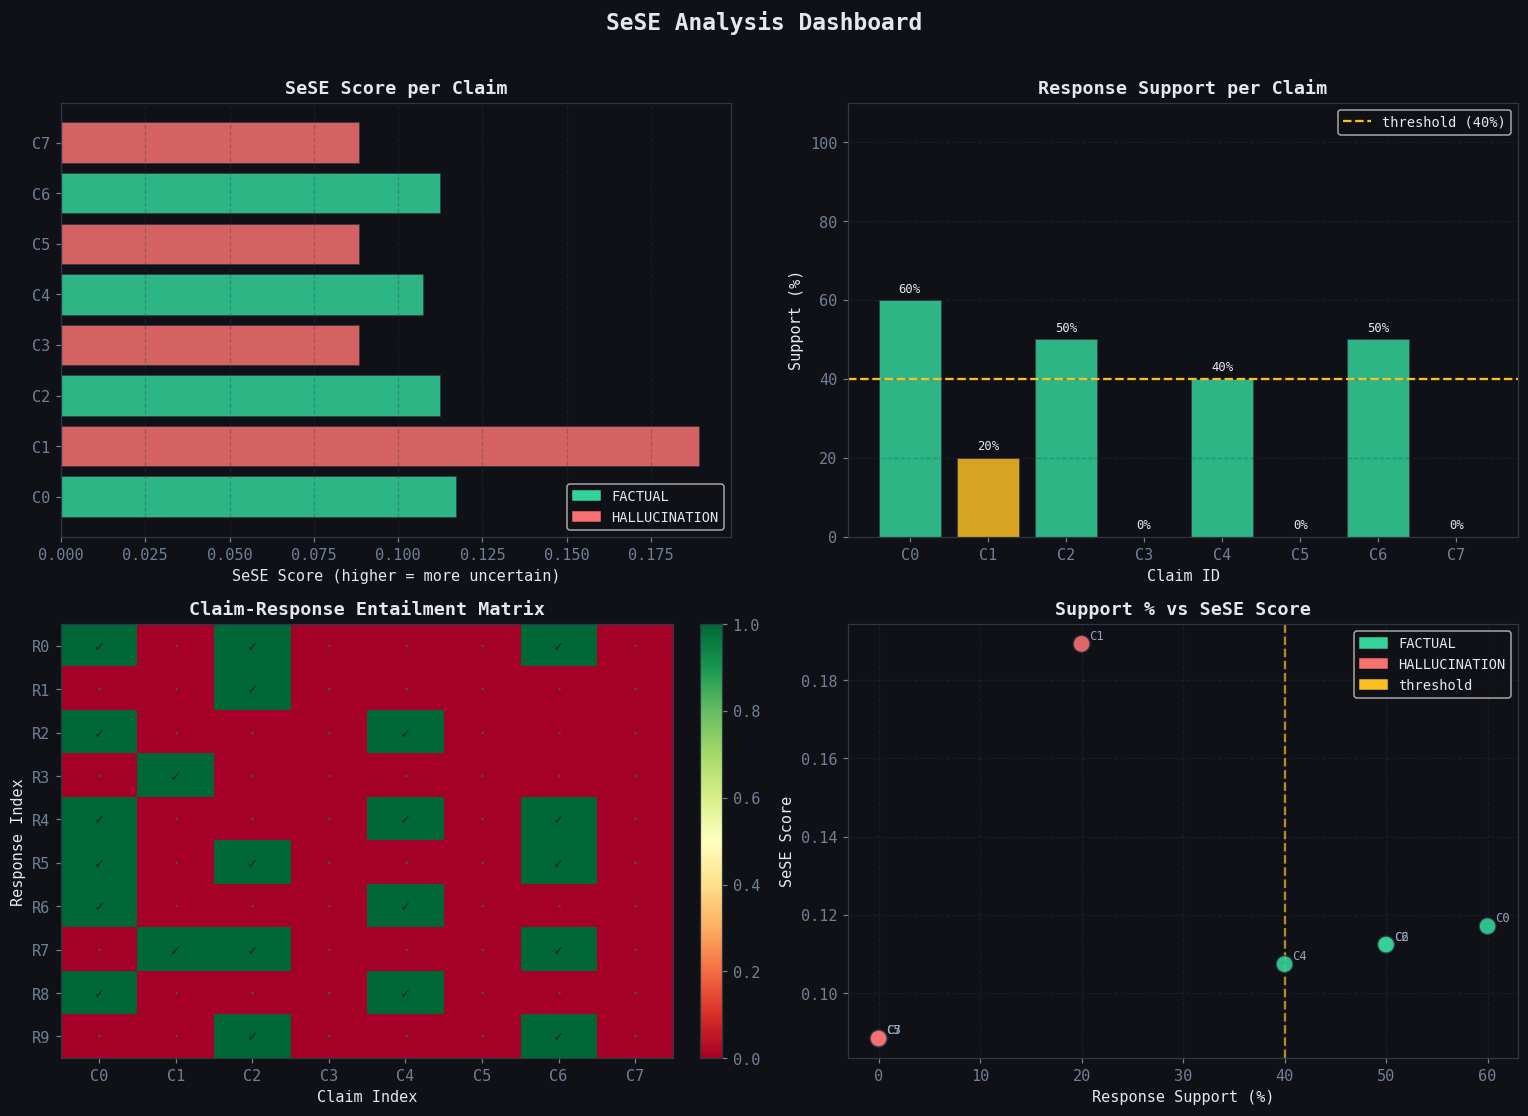

 Dashboard saved to /tmp/sese_dashboard.png


In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("SeSE Analysis Dashboard", fontsize=15, fontweight="bold", y=1.01)

GREEN  = "#34d399"
RED    = "#f87171"
BLUE   = "#60a5fa"
AMBER  = "#fbbf24"
PURPLE = "#a78bfa"

# ── Plot 1: SeSE scores per claim ─────────────────────────────────────────────
ax = axes[0, 0]
colors_bar = [RED if r.label == "HALLUCINATION" else GREEN for r in results]
bars = ax.barh(
    [f"C{r.claim_id}" for r in results],
    [r.sese_score for r in results],
    color=colors_bar, edgecolor="#2d3748", linewidth=0.5, alpha=0.85
)
ax.set_title("SeSE Score per Claim", fontweight="bold")
ax.set_xlabel("SeSE Score (higher = more uncertain)")
ax.axvline(0, color="#4a5568", lw=0.8, ls="--")
ax.grid(True, axis="x", alpha=0.3)

legend_elements = [
    mpatches.Patch(color=GREEN, label="FACTUAL"),
    mpatches.Patch(color=RED,   label="HALLUCINATION"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

# ── Plot 2: Support % per claim ───────────────────────────────────────────────
ax = axes[0, 1]
support_vals = [r.support_pct for r in results]
bar_colors   = [GREEN if v >= 40 else AMBER if v >= 20 else RED for v in support_vals]

ax.bar([f"C{r.claim_id}" for r in results], support_vals,
       color=bar_colors, edgecolor="#2d3748", linewidth=0.5, alpha=0.85)
ax.axhline(40, color=AMBER, lw=1.5, ls="--", label="threshold (40%)")
ax.set_title("Response Support per Claim", fontweight="bold")
ax.set_xlabel("Claim ID"); ax.set_ylabel("Support (%)")
ax.set_ylim(0, 110)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(fontsize=9)

for i, v in enumerate(support_vals):
    ax.text(i, v + 2, f"{v:.0f}%", ha="center", fontsize=8, color="#e2e8f0")

# ── Plot 3: Entailment heatmap ────────────────────────────────────────────────
ax = axes[1, 0]
E_np = DEMO_ENTAILMENT.detach().numpy()
im = ax.imshow(E_np, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_title("Claim-Response Entailment Matrix", fontweight="bold")
ax.set_xlabel("Claim Index"); ax.set_ylabel("Response Index")
ax.set_xticks(range(len(DEMO_CLAIMS)))
ax.set_xticklabels([f"C{i}" for i in range(len(DEMO_CLAIMS))])
ax.set_yticks(range(len(DEMO_RESPONSES)))
ax.set_yticklabels([f"R{i}" for i in range(len(DEMO_RESPONSES))])

for r in range(E_np.shape[0]):
    for c in range(E_np.shape[1]):
        ax.text(c, r, "✓" if E_np[r, c] == 1 else "·",
                ha="center", va="center", fontsize=10,
                color="#1a2235" if E_np[r, c] == 1 else "#4a5568")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ── Plot 4: Support vs SeSE scatter ──────────────────────────────────────────
ax = axes[1, 1]
x_vals = [r.support_pct for r in results]
y_vals = [r.sese_score  for r in results]
colors_sc = [RED if r.label == "HALLUCINATION" else GREEN for r in results]

sc = ax.scatter(x_vals, y_vals, c=colors_sc, s=120,
                edgecolors="#2d3748", linewidths=0.8, alpha=0.9, zorder=5)

ax.axvline(40, color=AMBER, lw=1.5, ls="--", alpha=0.7, label="support threshold (40%)")

for r in results:
    ax.annotate(f"C{r.claim_id}", (r.support_pct, r.sese_score),
                textcoords="offset points", xytext=(5, 3),
                fontsize=8, color="#94a3b8")

ax.set_title("Support % vs SeSE Score", fontweight="bold")
ax.set_xlabel("Response Support (%)"); ax.set_ylabel("SeSE Score")
ax.grid(True, alpha=0.3)
ax.legend(handles=legend_elements + [
    mpatches.Patch(color=AMBER, label="threshold")
], fontsize=9)

plt.tight_layout()
plt.savefig("/tmp/sese_dashboard.png", dpi=130, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()
print(" Dashboard saved to /tmp/sese_dashboard.png")


## 14. Training Demo

Simulate a small labelled dataset and fine-tune `SeSEParams`.
In production: use real NLI scores and verified hallucination labels.


In [ ]:
def make_synthetic_dataset(n_samples: int = 30) -> List[Dict]:
    """
    Create synthetic training examples.
    'hallucinating' = high-variance NLI scores (contradictory responses)
    'factual'       = low-variance NLI scores (consistent responses)
    """
    dataset = []
    for _ in range(n_samples):
        is_halluc = np.random.rand() > 0.5
        N = np.random.randint(4, 8)

        nli = []
        for i in range(N):
            row = []
            for j in range(N):
                if i == j:
                    row.append(NLIScore(1, 0, 0))
                else:
                    if is_halluc:
                        # hallucinating: high contradiction, low entailment
                        pe = np.random.uniform(0.05, 0.25)
                        pc = np.random.uniform(0.40, 0.70)
                    else:
                        # factual: high entailment, low contradiction
                        pe = np.random.uniform(0.55, 0.90)
                        pc = np.random.uniform(0.01, 0.15)
                    pn = max(0, 1 - pe - pc)
                    total = pe + pn + pc
                    row.append(NLIScore(pe/total, pn/total, pc/total))
            nli.append(row)

        dataset.append({"nli": nli, "label": int(is_halluc)})

    n_pos = sum(d["label"] for d in dataset)
    print(f"Dataset: {len(dataset)} samples | {n_pos} hallucinating | {len(dataset)-n_pos} factual")
    return dataset


# ── Create dataset and train ─────────────────────────────────────────────────
train_params  = SeSEParams()
train_dataset = make_synthetic_dataset(n_samples=40)

trainer = SeSETrainer(train_params, lr=5e-3, K=2)
losses  = trainer.train(train_dataset, epochs=50, batch_size=4, verbose=True)


Dataset: 40 samples | 22 hallucinating | 18 factual
Training SeSEParams  |  lr=0.005
Dataset size: 40  |  Epochs: 50  |  Batch: 4
Initial params:
  alpha  (entailment weight): 1.0
  beta   (neutral weight): 0.5
  gamma  (contradiction weight): 0.0
  merge_threshold: 0.0
  depth_discount: 1.0
  temperature: 1.0
  sparsity_threshold: 0.15
  lazy_weight: 0.1

Epoch   1/50  |  Loss: 0.7520
Epoch  11/50  |  Loss: 0.7121
Epoch  21/50  |  Loss: 0.6943


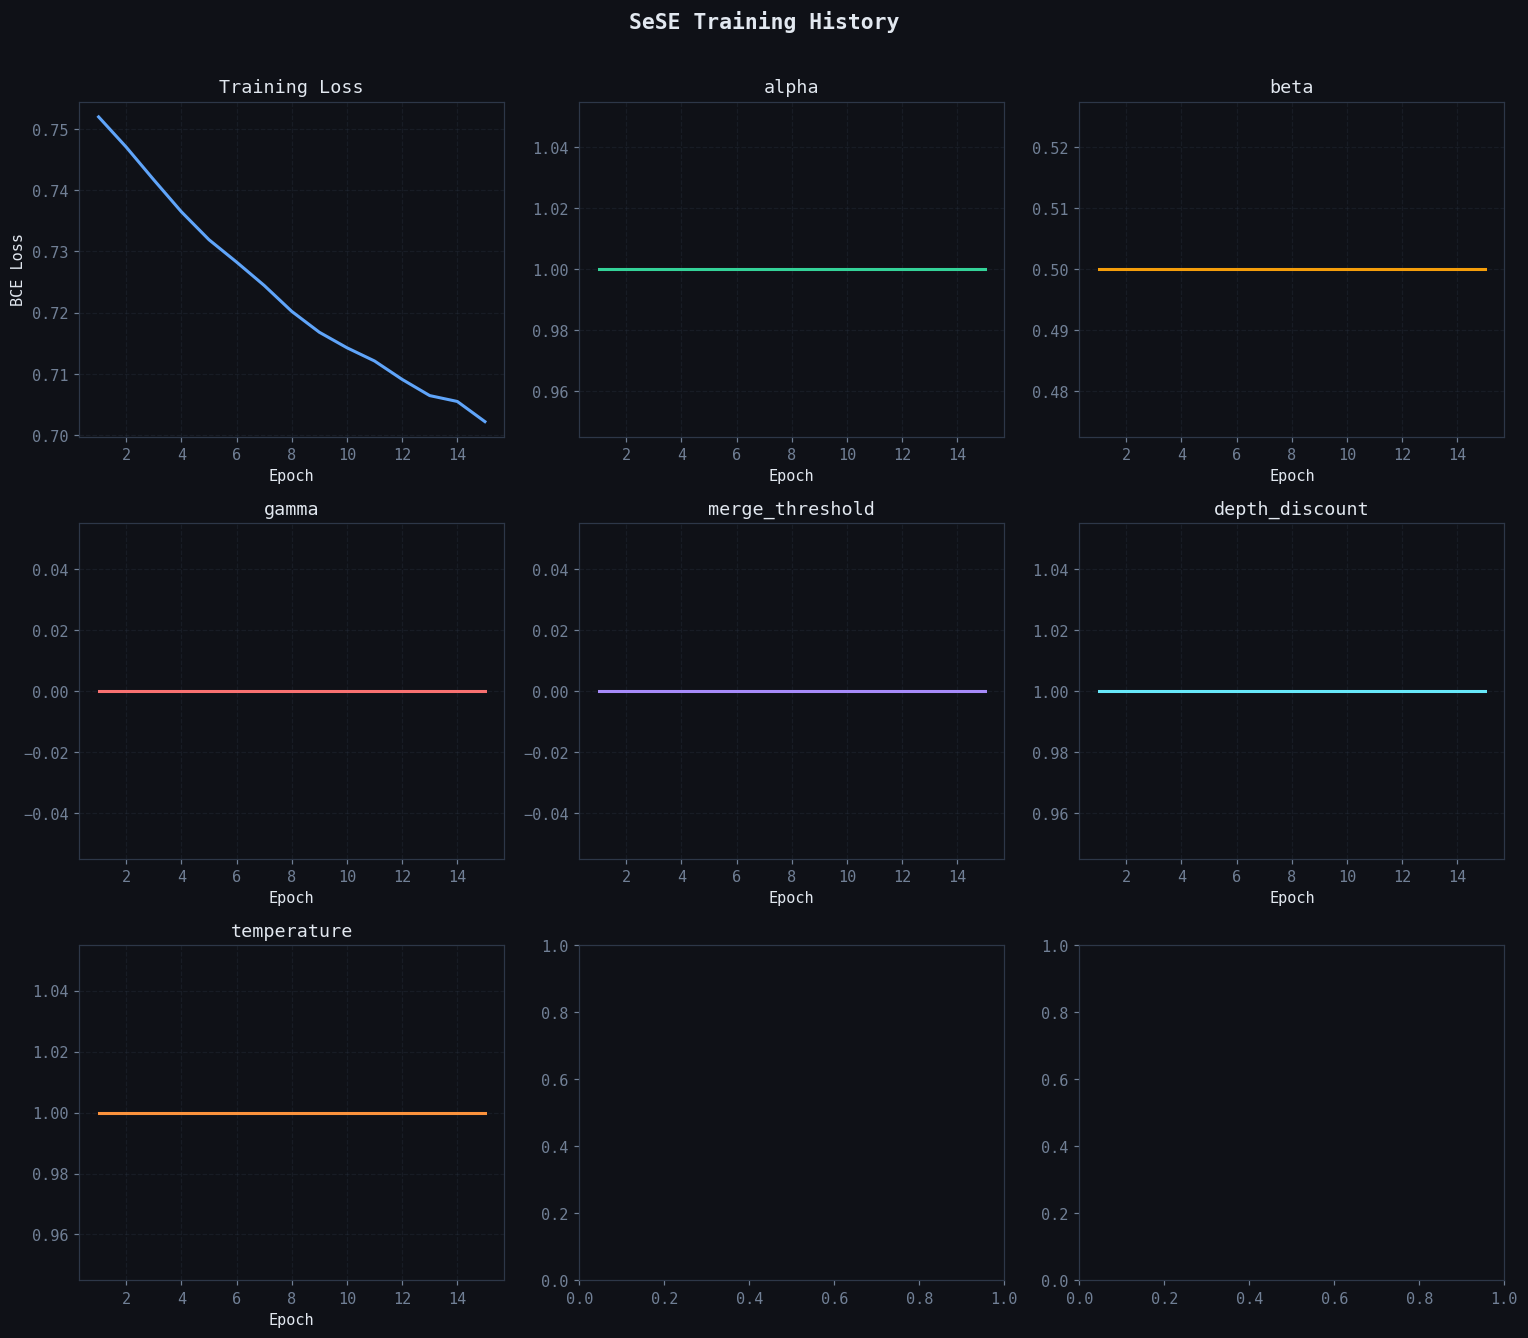

In [ ]:
# ── Plot training curves ──────────────────────────────────────────────────────
trainer.plot_training()


## 15. Hyperparameter Sensitivity Analysis

Sweep each trainable parameter while holding others fixed.
Observe how the hallucination classification changes.


In [ ]:
def sweep_parameter(param_name: str,
                    values: np.ndarray,
                    entailment: torch.Tensor,
                    claims: List[str],
                    responses: List[str]) -> pd.DataFrame:
    """
    Sweep a single parameter and record how claim labels change.
    """
    records = []
    for val in values:
        p = SeSEParams()
        with torch.no_grad():
            if param_name == "alpha":
                p.log_alpha.fill_(np.log(max(val, 1e-6)))
            elif param_name == "beta":
                p.log_beta.fill_(np.log(max(val, 1e-6)))
            elif param_name == "gamma":
                p.log_gamma.fill_(np.log(max(val, 1e-6)))
            elif param_name == "temperature":
                p.log_temperature.fill_(np.log(max(val, 0.1)))
            elif param_name == "depth_discount":
                # sigmoid(x)*2 = val → x = logit(val/2)
                v = np.clip(val / 2.0, 0.01, 0.99)
                p.log_depth_discount.fill_(float(np.log(v / (1 - v))))
            elif param_name == "threshold":
                p.merge_threshold.fill_(float(val))

        m = SeSELongForm(p, K=2)
        res = m.forward(entailment, claims, responses, threshold=0.4)

        n_halluc = sum(1 for r in res if r.label == "HALLUCINATION")
        avg_sese = np.mean([r.sese_score for r in res])

        records.append({
            "param_value":    round(float(val), 3),
            "n_hallucination": n_halluc,
            "n_factual":       len(res) - n_halluc,
            "avg_sese":        round(avg_sese, 4),
        })

    return pd.DataFrame(records)


# ── Run sweeps ────────────────────────────────────────────────────────────────
print("Running parameter sweeps (this may take ~30 seconds)…")

sweeps = {
    "alpha":       np.linspace(0.2, 2.0, 8),
    "beta":        np.linspace(0.0, 1.0, 8),
    "temperature": np.linspace(0.2, 3.0, 8),
}

sweep_results = {}
for pname, pvals in sweeps.items():
    df = sweep_parameter(pname, pvals, DEMO_ENTAILMENT, DEMO_CLAIMS, DEMO_RESPONSES)
    sweep_results[pname] = df
    print(f"  {pname} sweep done")

print("\nAll sweeps complete!")


Running parameter sweeps (this may take ~30 seconds)…
  alpha sweep done
  beta sweep done
  temperature sweep done

All sweeps complete!


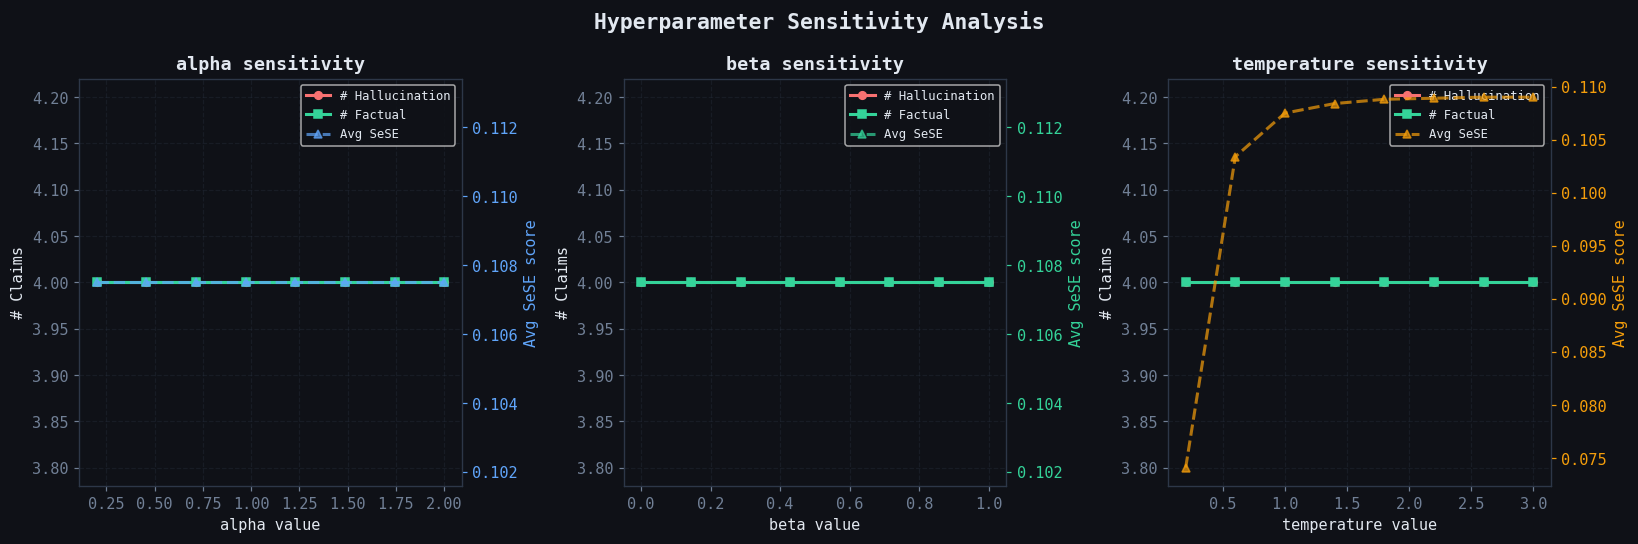

 Sensitivity plot saved to /tmp/sese_sensitivity.png


In [ ]:
# ── Plot sensitivity ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Hyperparameter Sensitivity Analysis", fontsize=14, fontweight="bold")

param_colors = {"alpha": "#60a5fa", "beta": "#34d399", "temperature": "#f59e0b"}

for ax, (pname, df) in zip(axes, sweep_results.items()):
    color = param_colors[pname]
    ax2   = ax.twinx()

    ax.plot(df["param_value"], df["n_hallucination"],
            color=RED, lw=2, marker="o", ms=5, label="# Hallucination")
    ax.plot(df["param_value"], df["n_factual"],
            color=GREEN, lw=2, marker="s", ms=5, label="# Factual")
    ax2.plot(df["param_value"], df["avg_sese"],
             color=color, lw=2, ls="--", marker="^", ms=5, alpha=0.7, label="Avg SeSE")

    ax.set_title(f"{pname} sensitivity", fontweight="bold")
    ax.set_xlabel(f"{pname} value")
    ax.set_ylabel("# Claims")
    ax2.set_ylabel("Avg SeSE score", color=color)
    ax2.tick_params(axis="y", colors=color)
    ax.grid(True, alpha=0.3)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="best")

plt.tight_layout()
plt.savefig("/tmp/sese_sensitivity.png", dpi=120, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()
print(" Sensitivity plot saved to /tmp/sese_sensitivity.png")


## 16. Threshold Sweep — Precision / Recall Tradeoff

Vary the support threshold (0–100%) and observe how many claims
are classified as hallucinations vs. factual.


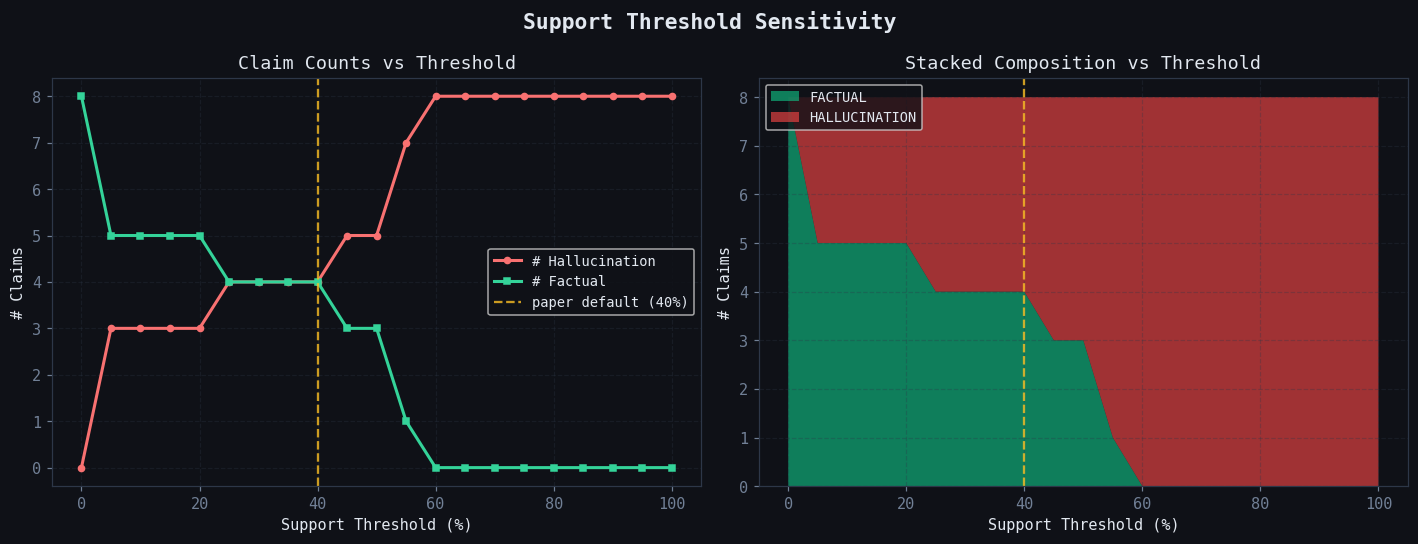

In [ ]:
thresholds   = np.linspace(0.0, 1.0, 21)
n_halluc_lst = []
n_factual_lst = []
avg_sese_lst  = []

params_thr = SeSEParams()
model_thr  = SeSELongForm(params_thr, K=2)

for thr in thresholds:
    res = model_thr.forward(DEMO_ENTAILMENT, DEMO_CLAIMS, DEMO_RESPONSES, threshold=thr)
    n_h = sum(1 for r in res if r.label == "HALLUCINATION")
    n_f = len(res) - n_h
    avg_s = np.mean([r.sese_score for r in res])
    n_halluc_lst.append(n_h)
    n_factual_lst.append(n_f)
    avg_sese_lst.append(avg_s)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Support Threshold Sensitivity", fontsize=14, fontweight="bold")

ax = axes[0]
ax.plot(thresholds * 100, n_halluc_lst, color=RED,   lw=2, marker="o", ms=4, label="# Hallucination")
ax.plot(thresholds * 100, n_factual_lst, color=GREEN, lw=2, marker="s", ms=4, label="# Factual")
ax.axvline(40, color=AMBER, lw=1.5, ls="--", alpha=0.8, label="paper default (40%)")
ax.set_xlabel("Support Threshold (%)")
ax.set_ylabel("# Claims")
ax.set_title("Claim Counts vs Threshold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.stackplot(
    thresholds * 100,
    n_factual_lst,
    [nh for nh in n_halluc_lst],
    labels=["FACTUAL", "HALLUCINATION"],
    colors=["#10b981", "#ef4444"],
    alpha=0.65,
)
ax.axvline(40, color=AMBER, lw=1.5, ls="--", alpha=0.8)
ax.set_xlabel("Support Threshold (%)")
ax.set_ylabel("# Claims")
ax.set_title("Stacked Composition vs Threshold")
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/sese_threshold.png", dpi=120, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()


## 17. Export Full Results

In [ ]:
import json

# Final classification with paper default parameters
params_final = SeSEParams()
model_final  = SeSELongForm(params_final, K=3)

final_results = model_final.forward(
    entailment = DEMO_ENTAILMENT,
    claims     = DEMO_CLAIMS,
    responses  = DEMO_RESPONSES,
    threshold  = 0.4
)

export = {
    "params": params_final.summary(),
    "threshold": 0.4,
    "claims": [
        {
            "id":            r.claim_id,
            "text":          r.claim_text,
            "sese_score":    r.sese_score,
            "label":         r.label,
            "confidence":    r.confidence,
            "support_pct":   r.support_pct,
            "support_count": r.support_count,
        }
        for r in final_results
    ],
    "responses": DEMO_RESPONSES,
    "entailment_matrix": DEMO_ENTAILMENT.tolist(),
    "summary": {
        "total_claims":   len(final_results),
        "n_factual":      sum(1 for r in final_results if r.label == "FACTUAL"),
        "n_hallucination":sum(1 for r in final_results if r.label == "HALLUCINATION"),
        "avg_sese_score": round(np.mean([r.sese_score for r in final_results]), 4),
    }
}

# Print
print(json.dumps(export, indent=2))
print()
print("=" * 60)
print(f"  FINAL SUMMARY")
print(f"  Total claims:     {export['summary']['total_claims']}")
print(f"  Factual:          {export['summary']['n_factual']}")
print(f"  Hallucinations:   {export['summary']['n_hallucination']}")
print(f"  Avg SeSE score:   {export['summary']['avg_sese_score']}")
print("=" * 60)


{
  "params": {
    "alpha  (entailment weight)": 1.0,
    "beta   (neutral weight)": 0.5,
    "gamma  (contradiction weight)": 0.0,
    "merge_threshold": 0.0,
    "depth_discount": 1.0,
    "temperature": 1.0,
    "sparsity_threshold": 0.15,
    "lazy_weight": 0.1
  },
  "threshold": 0.4,
  "claims": [
    {
      "id": 0,
      "text": "Mount Everest is the highest mountain in the world.",
      "sese_score": 0.1171,
      "label": "FACTUAL",
      "confidence": 0.5,
      "support_pct": 60.0,
      "support_count": 6
    },
    {
      "id": 1,
      "text": "The Great Wall of China is visible from space with the naked eye.",
      "sese_score": 0.1893,
      "label": "HALLUCINATION",
      "confidence": 0.5,
      "support_pct": 20.0,
      "support_count": 2
    },
    {
      "id": 2,
      "text": "Water boils at 100 degrees Celsius at sea level.",
      "sese_score": 0.1124,
      "label": "FACTUAL",
      "confidence": 0.25,
      "support_pct": 50.0,
      "support_count": 5

## 18. Production Integration Guide

### Replacing Mock NLI with Real Models

```python
# Option A: DeBERTa-v3-large-mnli (paper's approach)
from transformers import pipeline

nli_pipe = pipeline("zero-shot-classification",
                    model="cross-encoder/nli-deberta-v3-large")

def real_nli(premise: str, hypothesis: str) -> NLIScore:
    result = nli_pipe(hypothesis, candidate_labels=[premise],
                      hypothesis_template="{}")
    # Map scores to entailment/neutral/contradiction
    ...

# Option B: GPT-based entailment (paper's choice for long-form)
import openai

def gpt_entailment(response: str, claim: str) -> bool:
    prompt = f"""Context: {response}
Claim: {claim}
Is the claim supported by the context above? Answer Yes or No:"""
    result = openai.chat.completions.create(...)
    return result.choices[0].message.content.strip() == "Yes"
```

### Training on Real Data

```python
# 1. Collect labelled hallucination examples
dataset = [
    {"nli": compute_nli_matrix(responses_for_query_i), "label": 1},  # hallucinating
    {"nli": compute_nli_matrix(responses_for_query_j), "label": 0},  # factual
    ...
]

# 2. Fine-tune
params  = SeSEParams()
trainer = SeSETrainer(params, lr=1e-3, K=3)
trainer.train(dataset, epochs=20, batch_size=8)

# 3. Deploy
model = SeSEShortForm(params, K=3)
score = model(compute_nli_matrix(new_responses))
print("UNCERTAIN" if score > 0.5 else "CERTAIN")
```

### Key Design Choices

| Decision | Options | Recommendation |
|----------|---------|----------------|
| NLI model | DeBERTa, GPT-5-mini, Qwen | GPT-5-mini for long-form, DeBERTa for speed |
| Tree height K | 1–5 | 2–3 for most tasks; higher K for complex domains |
| Support threshold | 0.2–0.8 | 0.4 (40%) matches paper; tune on validation set |
| Training signal | BCE, ranking loss | BCE works well; ranking loss if scores needed |
| Batch size | 2–16 | 4–8 (limited by NLI computation) |
